
# 03 PyTorch Fundamentals: Tensors, Autograd, and a Real Training Loop

Notebook 02's forensic checks were rule-based no training required, which is exactly why they work
from day one. Eventually, once enough real flagged/reviewed documents accumulate, a **trained
classifier** can learn subtler patterns than fixed rules can capture. This notebook builds the PyTorch
foundation for that ending with a real, working, trained model, not just theory.

## Tensors PyTorch's core data structure

A tensor is PyTorch's version of a NumPy array, with one crucial addition: **it can track the operations
performed on it, so PyTorch can automatically compute gradients** the mechanism that makes training
possible.


In [5]:

import torch
import numpy as np

# Tensors look and behave a lot like NumPy arrays
x = torch.tensor([1.0, 2.0, 3.0])
y = torch.tensor([4.0, 5.0, 6.0])
print("x + y =", x + y)
print("x . y (dot product) =", torch.dot(x, y))

# Converting between NumPy and PyTorch is nearly free
np_array = np.array([1.0, 2.0, 3.0])
from_numpy = torch.from_numpy(np_array)
print("From NumPy:", from_numpy)


x + y = tensor([5., 7., 9.])
x . y (dot product) = tensor(32.)
From NumPy: tensor([1., 2., 3.], dtype=torch.float64)



## Autograd automatic differentiation

Set `requires_grad=True` on a tensor, and PyTorch tracks every operation performed on it, building a
computation graph. Calling `.backward()` on the final result computes the gradient of that result with
respect to every tensor that fed into it automatically, with no calculus written by hand.


In [6]:

# A tiny concrete example: if y = x^2, dy/dx = 2x. Let's confirm PyTorch computes this correctly.
x = torch.tensor(3.0, requires_grad=True)
y = x ** 2

y.backward()  # computes dy/dx and stores it in x.grad

print(f"x = {x.item()}, y = x^2 = {y.item()}")
print(f"dy/dx computed by autograd: {x.grad.item()} (should be 2*3 = 6)")


x = 3.0, y = x^2 = 9.0
dy/dx computed by autograd: 6.0 (should be 2*3 = 6)



This is the exact mechanism a neural network's training loop uses at every step: compute a prediction,
compare it to the correct answer (the "loss"), then call `.backward()` to find out how to adjust every
weight in the network to reduce that loss.

## Building a small CNN for image classification

The task: classify small image patches as showing a **tampering signature** or **genuine** content
directly automating the kind of visual judgment a human reviewer makes when looking at an ELA output
from notebook 02.

A **convolutional layer** slides small filters across an image, learning to detect local patterns (edges,
textures, blotches) the standard building block for any image classification task.


In [7]:

import torch.nn as nn
import torch.nn.functional as F

class TamperDetectorCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(32 * 8 * 8, 64)
        self.fc2 = nn.Linear(64, 2)  # 2 classes: genuine, tampered

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))   # 32x32 -> 16x16
        x = self.pool(F.relu(self.conv2(x)))   # 16x16 -> 8x8
        x = x.view(x.size(0), -1)              # flatten
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = TamperDetectorCNN()
print(model)

n_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal trainable parameters: {n_params:,}")


TamperDetectorCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=2048, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=2, bias=True)
)

Total trainable parameters: 136,354



## Generating a synthetic training dataset

Same honest caveat as always: this is synthetic data standing in for real labeled ELA patches. The
pattern it's simulating: "genuine" patches have low, uniform noise; "tampered" patches have a
brighter, more concentrated anomaly mimicking what a real ELA-flagged region looks like.


In [8]:

def make_patch(tampered: bool, size=32):
    base = np.random.normal(20, 5, (size, size, 3))  # low baseline noise, like a genuine ELA patch
    if tampered:
        # add a brighter, concentrated blob like a real tampering signature
        cy, cx = np.random.randint(8, size - 8, 2)
        yy, xx = np.ogrid[:size, :size]
        blob = np.exp(-((yy - cy)**2 + (xx - cx)**2) / (2 * 5**2)) * np.random.uniform(80, 150)
        base += blob[..., None]
    patch = np.clip(base, 0, 255).astype(np.uint8)
    return patch

np.random.seed(4)
n_samples = 800
patches = []
labels = []
for i in range(n_samples):
    is_tampered = i % 2 == 0
    patches.append(make_patch(is_tampered))
    labels.append(1 if is_tampered else 0)

patches = np.array(patches)
labels = np.array(labels)

# Convert to PyTorch tensors: (N, H, W, C) -> (N, C, H, W), which is the layout PyTorch expects,
# and scale pixel values to 0-1
X = torch.from_numpy(patches).permute(0, 3, 1, 2).float() / 255.0
y = torch.from_numpy(labels).long()

print("X shape:", X.shape, " (batch, channels, height, width)")
print("y shape:", y.shape)


X shape: torch.Size([800, 3, 32, 32])  (batch, channels, height, width)
y shape: torch.Size([800])


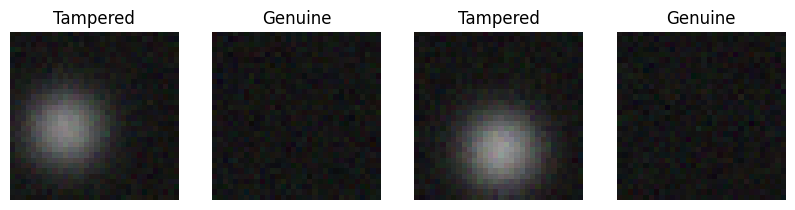

In [9]:

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(10, 3))
for i in range(4):
    axes[i].imshow(patches[i])
    axes[i].set_title("Tampered" if labels[i] == 1 else "Genuine")
    axes[i].axis("off")
plt.show()



## Splitting into train/test and writing the training loop

This is the standard PyTorch training loop shape you'll see this exact structure in almost every
PyTorch project, real or tutorial.


In [10]:

from torch.utils.data import TensorDataset, DataLoader, random_split

dataset = TensorDataset(X, y)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_ds, test_ds = random_split(dataset, [train_size, test_size], generator=torch.Generator().manual_seed(0))

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=32)

model = TamperDetectorCNN()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.CrossEntropyLoss()

n_epochs = 5
for epoch in range(n_epochs):
    model.train()
    total_loss = 0.0
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()               # reset gradients from the previous step
        predictions = model(batch_x)         # forward pass
        loss = loss_fn(predictions, batch_y) # how wrong were we
        loss.backward()                      # autograd computes all gradients
        optimizer.step()                     # update weights using those gradients
        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{n_epochs} average training loss: {total_loss/len(train_loader):.4f}")


Epoch 1/5 average training loss: 0.5469
Epoch 2/5 average training loss: 0.0415
Epoch 3/5 average training loss: 0.0004
Epoch 4/5 average training loss: 0.0001
Epoch 5/5 average training loss: 0.0000


In [11]:

# Evaluate on the held-out test set
model.eval()
correct = 0
total = 0
with torch.no_grad():  # no need to track gradients during evaluation saves memory and time
    for batch_x, batch_y in test_loader:
        predictions = model(batch_x)
        predicted_labels = predictions.argmax(dim=1)
        correct += (predicted_labels == batch_y).sum().item()
        total += batch_y.size(0)

print(f"Test accuracy: {correct/total*100:.1f}%")


Test accuracy: 100.0%



Very high accuracy here is expected and **not impressive** this synthetic task is deliberately easy
(the tampered blobs are visually obvious by construction). Real document tampering is far subtler, which
is exactly why real training data and careful evaluation matter so much more than this toy example, and
why this feature is correctly sequenced late in the roadmap, after enough real flagged examples exist.

## Exercises

### Exercise 1
Modify `make_patch()` so the tampering signature is much subtler (a smaller, dimmer blob) and re-train.
Confirm that test accuracy drops a concrete demonstration of why real-world forensic classification is
harder than this toy version, and why threshold-tuning (from notebook 02) still matters even with a
trained model in the mix.


In [12]:
# Your code here


#### Solution

In [13]:

def make_subtle_patch(tampered: bool, size=32):
    base = np.random.normal(20, 5, (size, size, 3))
    if tampered:
        cy, cx = np.random.randint(8, size - 8, 2)
        yy, xx = np.ogrid[:size, :size]
        blob = np.exp(-((yy - cy)**2 + (xx - cx)**2) / (2 * 5**2)) * np.random.uniform(15, 25)  # much dimmer
        base += blob[..., None]
    return np.clip(base, 0, 255).astype(np.uint8)

np.random.seed(9)
subtle_patches = np.array([make_subtle_patch(i % 2 == 0) for i in range(400)])
subtle_labels = np.array([1 if i % 2 == 0 else 0 for i in range(400)])
X_subtle = torch.from_numpy(subtle_patches).permute(0, 3, 1, 2).float() / 255.0
y_subtle = torch.from_numpy(subtle_labels).long()

subtle_ds = TensorDataset(X_subtle, y_subtle)
subtle_loader = DataLoader(subtle_ds, batch_size=32)

model.eval()
correct = 0
with torch.no_grad():
    for bx, by in subtle_loader:
        preds = model(bx).argmax(dim=1)
        correct += (preds == by).sum().item()
print(f"Accuracy on subtler tampering (using the model trained on obvious tampering): {correct/len(subtle_ds)*100:.1f}%")
print("Expect this to be noticeably worse the model learned the obvious pattern, not a general one.")


Accuracy on subtler tampering (using the model trained on obvious tampering): 50.0%
Expect this to be noticeably worse the model learned the obvious pattern, not a general one.



### Exercise 2
Save the trained model's weights with `torch.save(model.state_dict(), "/tmp/tamper_model.pt")`, then
load them into a fresh `TamperDetectorCNN()` instance and confirm it produces the same predictions
this is the exact save/load pattern you'd use to persist a trained model between the training
environment and the production service.


In [14]:
# Your code here


#### Solution

In [15]:

torch.save(model.state_dict(), "/tmp/tamper_model.pt")

reloaded_model = TamperDetectorCNN()
reloaded_model.load_state_dict(torch.load("/tmp/tamper_model.pt"))
reloaded_model.eval()

sample_x, sample_y = next(iter(test_loader))
with torch.no_grad():
    original_preds = model(sample_x).argmax(dim=1)
    reloaded_preds = reloaded_model(sample_x).argmax(dim=1)

print("Predictions match after save/reload:", torch.equal(original_preds, reloaded_preds))


RuntimeError: Parent directory /tmp does not exist.


## What's next

Training a CNN from scratch, as above, needs a lot of data to generalize well hundreds of thousands of
images, typically, for real-world robustness. You won't have that early on. **`04_transfer_learning_torchvision.ipynb`**
covers the realistic alternative: starting from a model already trained on millions of general images,
and fine-tuning it on your much smaller dataset.
